In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

X_np = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_np = np.array([[0],[1],[1],[0]], dtype=np.float32)

X = torch.FloatTensor(X_np)
y = torch.FloatTensor(y_np)

labels_txt = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
renkler    = ['#c0392b', '#27ae60', '#27ae60', '#c0392b']

print('XOR Veri Seti:')
print(X_np)
print('Hedef y:', y_np.flatten())

XOR Veri Seti:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Hedef y: [0. 1. 1. 0.]


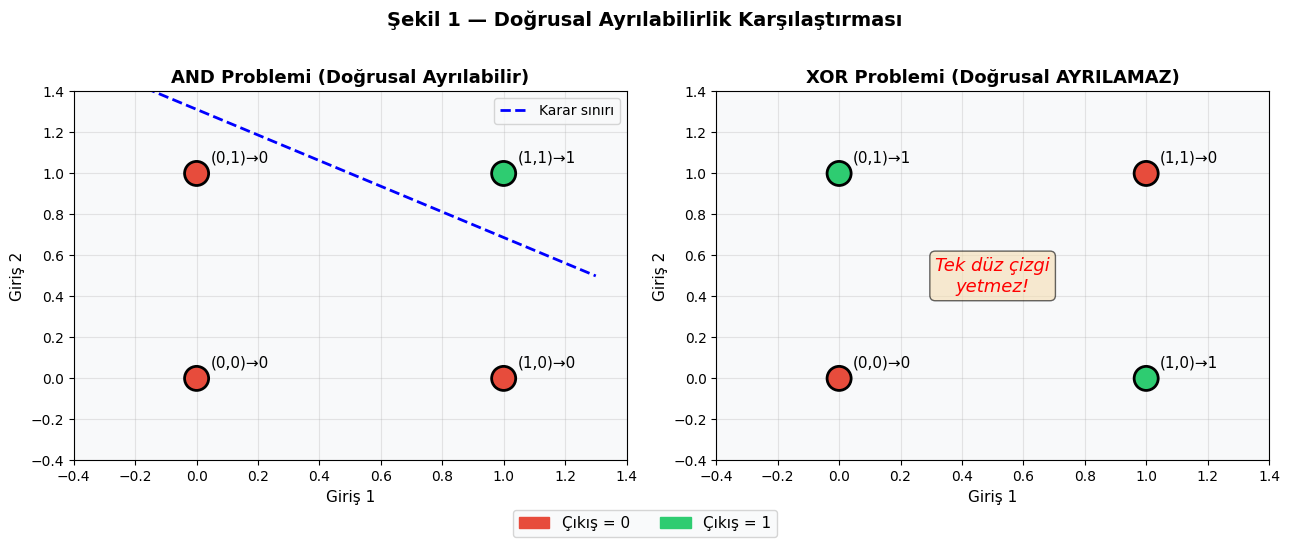

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_and = np.array([0, 0, 0, 1])
labels_and = ['(0,0)→0', '(0,1)→0', '(1,0)→0', '(1,1)→1']
colors_and = ['#e74c3c' if l == 0 else '#2ecc71' for l in y_and]
colors_xor = ['#e74c3c' if l == 0 else '#2ecc71' for l in y_np.flatten()]

for ax, title, show_line, colors_s, lbls in [
    (axes[0], 'AND Problemi (Doğrusal Ayrılabilir)', True,  colors_and, labels_and),
    (axes[1], 'XOR Problemi (Doğrusal AYRILAMAZ)',  False, colors_xor, labels_txt)
]:
    ax.scatter(X_np[:,0], X_np[:,1], c=colors_s, s=300, zorder=5, edgecolors='black', linewidth=2)
    for i, txt in enumerate(lbls):
        ax.annotate(txt, (X_np[i,0], X_np[i,1]), textcoords='offset points', xytext=(10,8), fontsize=11)
    if show_line:
        ax.plot([-0.3, 1.3], [1.5, 0.5], 'b--', lw=2, label='Karar sınırı')
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, 'Tek düz çizgi\nyetmez!', ha='center', va='center',
                fontsize=13, color='red', style='italic',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    ax.set_xlim(-0.4,1.4); ax.set_ylim(-0.4,1.4)
    ax.set_xlabel('Giriş 1', fontsize=11); ax.set_ylabel('Giriş 2', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold'); ax.grid(True, alpha=0.3)

fig.legend(handles=[mpatches.Patch(color='#e74c3c',label='Çıkış = 0'),
                    mpatches.Patch(color='#2ecc71',label='Çıkış = 1')],
           loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5,-0.05))
plt.suptitle('Şekil 1 — Doğrusal Ayrılabilirlik Karşılaştırması', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
torch.manual_seed(42)

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.katman1 = nn.Linear(2, 8)
        self.katman2 = nn.Linear(8, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.katman1(x))
        x = self.sigmoid(self.katman2(x))
        return x

model     = XORNet()
kayip_fn  = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

kayip_listesi = []
for epoch in range(5000):
    model.train()
    optimizer.zero_grad()
    cikis = model(X)
    kayip = kayip_fn(cikis, y)
    kayip.backward()
    optimizer.step()
    kayip_listesi.append(kayip.item())

model.eval()
with torch.no_grad():
    tahmin_ham   = model(X)
    tahmin_sinif = (tahmin_ham >= 0.5).float()

dogru = int((tahmin_sinif == y).sum())

print('PyTorch XOR Sinir Ağı')
print('Mimari : 2 → 8 (ReLU) → 1 (Sigmoid)')
print(f'Epoch  : 5000')
print(f'Son Kayıp: {kayip_listesi[-1]:.6f}')
print()
print('Giriş    | Hedef | Ham Çıkış | Tahmin')
print('-' * 42)
for i in range(4):
    g = X_np[i]
    print(f'[{int(g[0])}, {int(g[1])}]    |   {int(y_np[i][0])}   '
          f'|   {tahmin_ham[i][0]:.4f}    |   {int(tahmin_sinif[i][0])}')
print(f'\nDoğru tahmin: {dogru}/4  →  Accuracy: %{dogru/4*100:.0f}')

PyTorch XOR Sinir Ağı
Mimari : 2 → 8 (ReLU) → 1 (Sigmoid)
Epoch  : 5000
Son Kayıp: 0.000017

Giriş    | Hedef | Ham Çıkış | Tahmin
------------------------------------------
[0, 0]    |   0   |   0.0000    |   0
[0, 1]    |   1   |   1.0000    |   1
[1, 0]    |   1   |   1.0000    |   1
[1, 1]    |   0   |   0.0000    |   0

Doğru tahmin: 4/4  →  Accuracy: %100


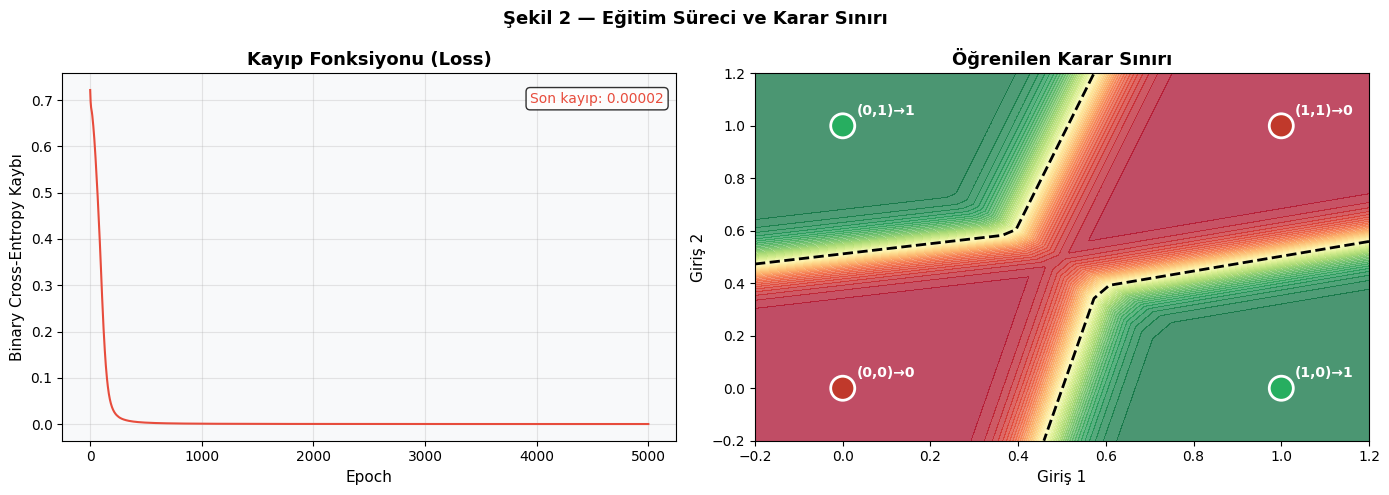

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kayip_listesi, color='#e74c3c', lw=1.5)
axes[0].set_title('Kayıp Fonksiyonu (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Binary Cross-Entropy Kaybı', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.98, 0.95, f'Son kayıp: {kayip_listesi[-1]:.5f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10,
             color='#e74c3c', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

xx, yy = np.meshgrid(np.linspace(-0.2,1.2,300), np.linspace(-0.2,1.2,300))
grid   = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    zz = model(grid).numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, zz, levels=50, cmap='RdYlGn', alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2, linestyles='--')
axes[1].scatter(X_np[:,0], X_np[:,1], c=renkler, s=300, zorder=5, edgecolors='white', linewidth=2)
for i, lbl in enumerate(labels_txt):
    axes[1].annotate(lbl, (X_np[i,0], X_np[i,1]),
                    textcoords='offset points', xytext=(10,8),
                    fontsize=10, color='white', fontweight='bold')
axes[1].set_title('Öğrenilen Karar Sınırı', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giriş 1', fontsize=11)
axes[1].set_ylabel('Giriş 2', fontsize=11)

plt.suptitle('Şekil 2 — Eğitim Süreci ve Karar Sınırı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_gercek = y_np.flatten().astype(int)
y_tahmin = tahmin_sinif.numpy().flatten().astype(int)

acc  = accuracy_score(y_gercek, y_tahmin)
prec = precision_score(y_gercek, y_tahmin, zero_division=0)
rec  = recall_score(y_gercek, y_tahmin, zero_division=0)
f1   = f1_score(y_gercek, y_tahmin, zero_division=0)
cm   = confusion_matrix(y_gercek, y_tahmin)

print('DEĞERLENDİRME METRİKLERİ')
print(f'Accuracy  : {acc:.4f}  (%{acc*100:.0f})')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print('Confusion Matrix:')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')

DEĞERLENDİRME METRİKLERİ
Accuracy  : 1.0000  (%100)
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Confusion Matrix:
  TN=2  FP=0
  FN=0  TP=2


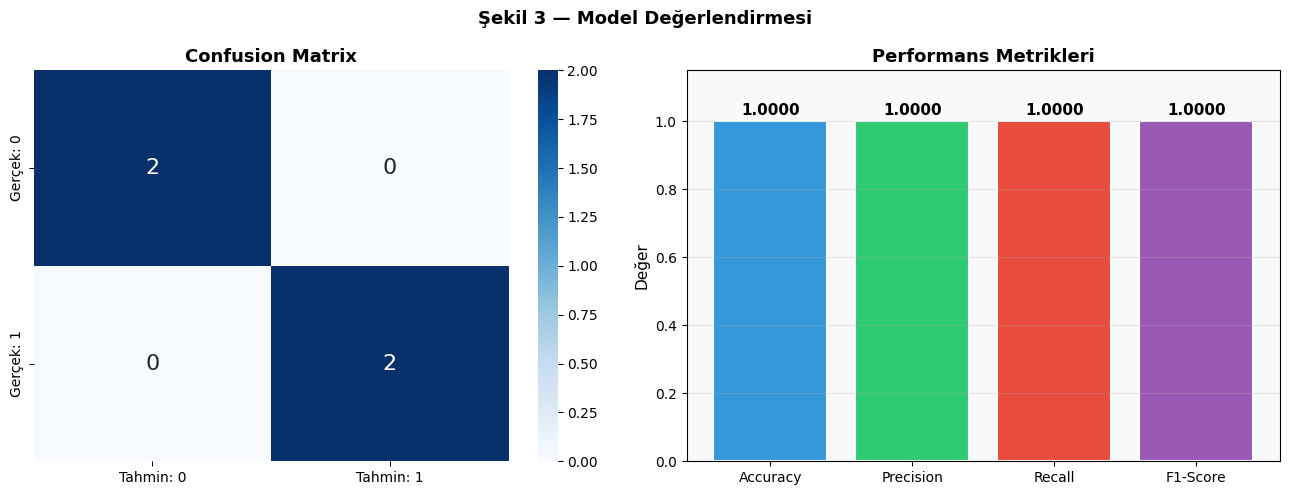

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tahmin: 0','Tahmin: 1'],
            yticklabels=['Gerçek: 0','Gerçek: 1'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

metrikler    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
degerler     = [acc, prec, rec, f1]
renkler_bar  = ['#3498db','#2ecc71','#e74c3c','#9b59b6']
bars = axes[1].bar(metrikler, degerler, color=renkler_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, degerler):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Performans Metrikleri', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Değer', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Şekil 3 — Model Değerlendirmesi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()